In [38]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [39]:
X=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]
)

y = np.array([
    0,
    1,
    1,
    0
])


In [40]:
#input layer
model=Sequential()
model.add(Dense(2, input_dim=2, activation='tanh'))
# Output layer
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.1),
    metrics=['accuracy']
)


In [42]:
history = model.fit(
    X, y,
    epochs=100,
    verbose=1   # set to 1 if you want to see training output
)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step - accuracy: 0.5000 - loss: 0.7203
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 0.6975
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 0.7014
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.7030
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5000 - loss: 0.6993
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5000 - loss: 0.6954
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 0.6942
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 0.6954
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 0.6966
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.6965
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 0.6954
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - 

In [43]:
# Predictions
predictions = model.predict(X)

print("Input  | Predicted | Rounded | Actual")
print("--------------------------------------")
for i in range(len(X)):
    print(f"{X[i]} | {predictions[i][0]:.4f}     | {int(round(predictions[i][0]))}       | {y[i]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Input  | Predicted | Rounded | Actual
--------------------------------------
[0 0] | 0.0055     | 0       | 0
[0 1] | 0.9820     | 1       | 1
[1 0] | 0.9876     | 1       | 1
[1 1] | 0.0055     | 0       | 0


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


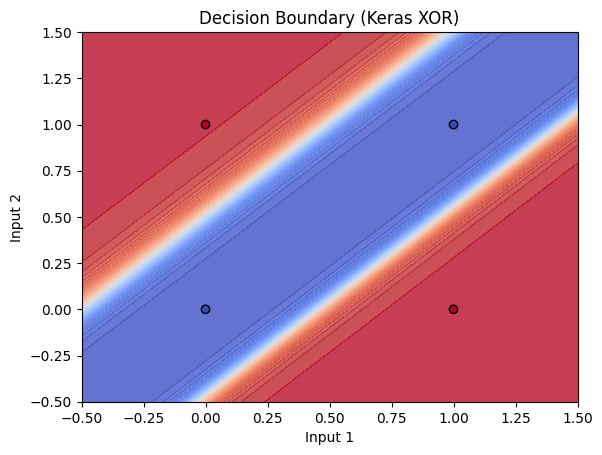

In [44]:
import matplotlib.pyplot as plt
# Create mesh grid
xx, yy = np.meshgrid(
    np.linspace(-0.5, 1.5, 200),
    np.linspace(-0.5, 1.5, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.8)
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='coolwarm')
plt.title("Decision Boundary (Keras XOR)")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()


PyTorch :


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim


In [19]:
# Input
X = torch.tensor([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

# Output
y = torch.tensor([
    [0.0],
    [1.0],
    [1.0],
    [0.0]
])


In [20]:
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.hidden = nn.Linear(2, 2)   # 2 input → 2 hidden neurons
        self.output = nn.Linear(2, 1)   # 2 hidden → 1 output
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.tanh(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x


In [21]:
model = XORNet()

criterion = nn.BCELoss()   # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.1)


In [32]:
epochs = 100

for epoch in range(epochs):
    optimizer.zero_grad()      # Clear gradients
    outputs = model(X)         # Forward pass
    loss = criterion(outputs, y)  # Compute loss
    loss.backward()            # Backpropagation
    optimizer.step()           # Update weights
print(f"Epoch {epoch+1}, Loss: {loss.item()}")


Epoch 100, Loss: 0.002429951447993517


loss decreases as epoch number increases


In [33]:
with torch.no_grad():
    predictions = model(X)

print("Input  | Predicted | Rounded | Actual")
print("--------------------------------------")
for i in range(len(X)):
    print(f"{X[i].tolist()} | {predictions[i].item():.4f}     | {round(predictions[i].item())}       | {int(y[i].item())}")


Input  | Predicted | Rounded | Actual
--------------------------------------
[0.0, 0.0] | 0.0015     | 0       | 0
[0.0, 1.0] | 0.9964     | 1       | 1
[1.0, 0.0] | 0.9967     | 1       | 1
[1.0, 1.0] | 0.0013     | 0       | 0


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

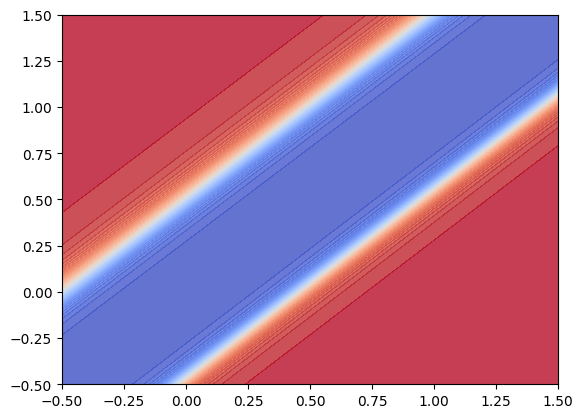

In [45]:
with torch.no_grad():
    Z = model(torch.tensor(grid, dtype=torch.float32))
    Z = Z.numpy().reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.8)
plt.scatter(X.numpy()[:,0], X.numpy()[:,1], c=y.numpy().flatten(), edgecolors='k', cmap='coolwarm')
plt.title("Decision Boundary (PyTorch XOR)")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()


tensorflow :

In [46]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [47]:
X = tf.constant([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
], dtype=tf.float32)

y = tf.constant([
    [0.],
    [1.],
    [1.],
    [0.]
], dtype=tf.float32)


In [48]:
# Hidden layer (2 neurons)
W1 = tf.Variable(tf.random.normal([2, 2]))
b1 = tf.Variable(tf.zeros([2]))

# Output layer (1 neuron)
W2 = tf.Variable(tf.random.normal([2, 1]))
b2 = tf.Variable(tf.zeros([1]))


In [49]:
def forward(x):
    hidden = tf.tanh(tf.matmul(x, W1) + b1)
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
    return output


In [51]:
loss_fn = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)


In [52]:
epochs = 50
losses = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = forward(X)
        loss = loss_fn(y, y_pred)

    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    losses.append(loss.numpy())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.numpy():.4f}")


Epoch [50/50], Loss: 0.0629


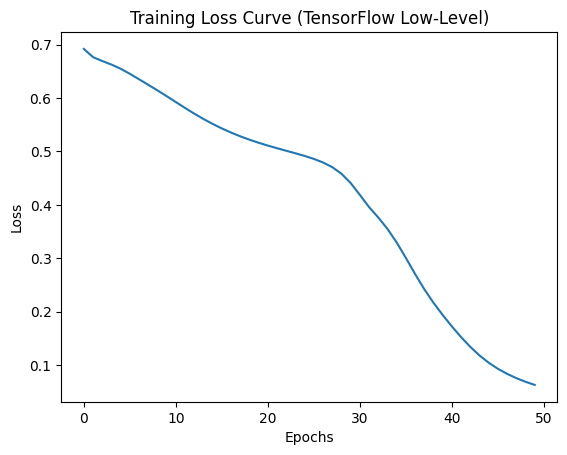

In [53]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve (TensorFlow Low-Level)")
plt.show()


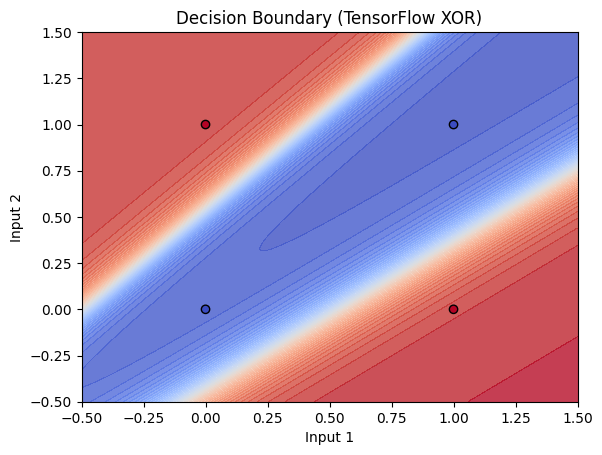

In [54]:
xx, yy = np.meshgrid(
    np.linspace(-0.5, 1.5, 200),
    np.linspace(-0.5, 1.5, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

Z = forward(tf.constant(grid))
Z = Z.numpy().reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.8)
plt.scatter(X[:,0], X[:,1], c=y[:,0], edgecolors='k', cmap='coolwarm')
plt.title("Decision Boundary (TensorFlow XOR)")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()
